# Блок 3. Продвинутый уровень. Занятие 12

# Корреляция и поиск зависимостей

## Теория

На прошлом занятии мы научились:
- загружать реальные данные;
- строить графики;
- искать максимум и минимум.

Сегодня изучаем:

- корреляцию;
- силу связи между признаками;
- матрицу корреляций;
- поиск полезных признаков;
- визуализацию зависимостей.

## Что такое корреляция

Корреляция показывает, насколько сильно связаны два числовых признака.

Примеры:

- рост и вес;
- длительность тренировки и потраченные калории;
- расходы на рекламу и продажи.

Значения:

- близко к +1 → сильная положительная связь;
- близко к -1 → сильная отрицательная связь;
- около 0 → связи почти нет.

## Практическое значение

В аналитике корреляция помогает:

- выбирать важные признаки;
- понимать данные;
- строить модели машинного обучения;
- объяснять результаты бизнеса.

## Связь с дипломом

Практически любой дипломный проект использует поиск зависимостей:

- HR;
- финансы;
- спорт;
- питание;
- недвижимость.


Сначала изучите SOLVED-ноутбук, затем выполните все задания самостоятельно.

## Ячейка 1. TODO: импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

assert pd is not None

## Ячейка 2. TODO: загрузка датасета

In [2]:
url = r"../data/FOT.csv"

df = pd.read_csv(url)

print("Первые строки датасета:")
display(df.head())

assert len(df) > 0


Первые строки датасета:


,Date,Protein,Fats,Sat Fats,Carbs,Sugars,Calories,Weight,Body Fat
0,23.08.07,111,47,24,170,69,2259,168.0,NaN
1,23.08.14,102,51,16,221,72,2252,172.0,NaN
2,23.08.21,113,56,18,231,77,2469,171.0,NaN
3,23.08.28,134,37,17,203,79,2259,171.5,NaN
4,23.09.04,142,49,13,253,71,2489,172.5,NaN


## Ячейка 3. TODO: выделите числовые признаки

In [3]:
numeric_df = df.select_dtypes(include=["number"])

print(numeric_df.columns.tolist())

assert numeric_df.shape[1] > 3


['Protein', 'Fats', 'Sat Fats', 'Carbs', 'Sugars', 'Calories', 'Weight', 'Body Fat']


## Ячейка 4. TODO: матрица корреляций

In [4]:
corr_matrix = numeric_df.corr()

display(corr_matrix.round(2))

assert(corr_matrix.shape[0] > 1)

,Protein,Fats,Sat Fats,Carbs,Sugars,Calories,Weight,Body Fat
Protein,1.00,-0.14,-0.14,-0.08,-0.13,0.10,-0.30,-0.12
Fats,-0.14,1.00,0.66,0.68,0.51,0.83,0.28,0.19
Sat Fats,-0.14,0.66,1.00,0.33,0.64,0.61,-0.13,-0.28
Carbs,-0.08,0.68,0.33,1.00,0.51,0.88,0.38,0.34
Sugars,-0.13,0.51,0.64,0.51,1.00,0.69,-0.25,-0.38
Calories,0.10,0.83,0.61,0.88,0.69,1.00,0.19,0.13
Weight,-0.30,0.28,-0.13,0.38,-0.25,0.19,1.00,1.00
Body Fat,-0.12,0.19,-0.28,0.34,-0.38,0.13,1.00,1.00


## Ячейка 5. TODO: найдите корреляции с total exports

In [5]:
target_corr = corr_matrix["Calories"].sort_values(ascending=False)

print(target_corr)

Calories    1.000000
Carbs       0.882698
Fats        0.830244
Sugars      0.689238
Sat Fats    0.611786
Weight      0.185010
Body Fat    0.131759
Protein     0.096179
Name: Calories, dtype: float64


## Ячейка 6. TODO: bar chart корреляций

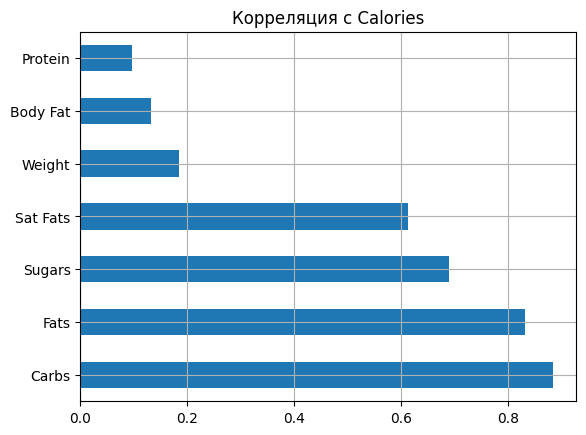

In [6]:
target_corr.drop("Calories").plot(kind="barh")
plt.title("Корреляция с Calories")
plt.grid(True)
plt.show()

## Ячейка 7. TODO: первый scatter

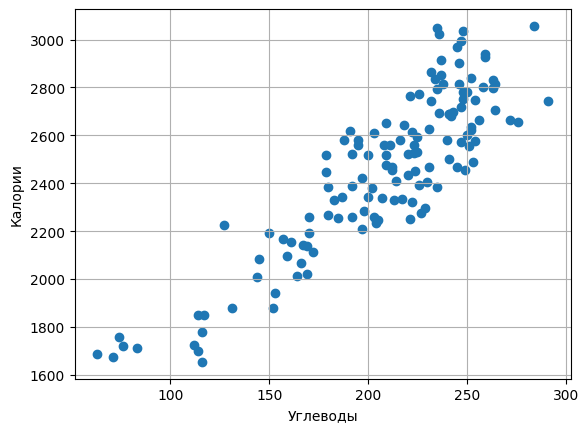

In [7]:
plt.scatter(df["Carbs"], df["Calories"])

plt.xlabel("Углеводы")
plt.ylabel("Калории")
plt.grid(True)


## Ячейка 8. TODO: второй scatter

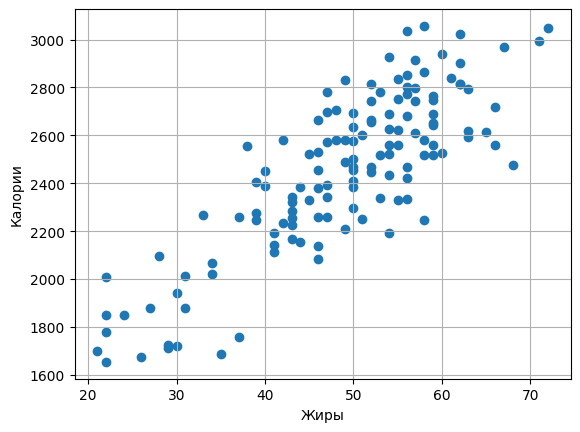

In [8]:
plt.scatter(df["Fats"], df["Calories"])

plt.xlabel("Жиры")
plt.ylabel("Калории")
plt.grid(True)


## Ячейка 9. TODO: найдите топ-5 корреляций

In [9]:
top_corr = (target_corr.drop("Calories").abs().sort_values(ascending=False).head(5))

print(top_corr)

assert len(top_corr) == 5

Carbs       0.882698
Fats        0.830244
Sugars      0.689238
Sat Fats    0.611786
Weight      0.185010
Name: Calories, dtype: float64


## Ячейка 10. TODO: выводы

In [10]:
print("Количество признаков:", len(numeric_df.columns))
print("Самая сильная связь:", top_corr.index[0])

assert len(numeric_df.columns) > 3


Количество признаков: 8
Самая сильная связь: Carbs
